# WiDS Datathon 2025: Final submission

# Project Objectives

# Data

In [170]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import linkage
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from xgboost import XGBClassifier


qm_data_path = "./widsdatathon2025/TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx"
fcm_data_path = "./widsdatathon2025/TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv"
cm_data_path = "./widsdatathon2025/TRAIN_NEW/TRAIN_CATEGORICAL_METADATA_new.xlsx"

y = pd.read_excel("./widsdatathon2025/TRAIN_NEW/TRAINING_SOLUTIONS.xlsx")



qm_df = pd.read_excel(qm_data_path)
fcm_df = pd.read_csv(fcm_data_path) #this is kinda big, hopefully we can process it a bit and create a new reduced file to load
cm_df = pd.read_excel(cm_data_path)
print(qm_df.shape)
print(fcm_df.shape)
print(cm_df.shape)

(1213, 19)
(1213, 19901)
(1213, 10)


In [171]:
print(qm_df.describe())

       EHQ_EHQ_Total  ColorVision_CV_Score  APQ_P_APQ_P_CP  APQ_P_APQ_P_ID  \
count    1200.000000           1190.000000     1201.000000     1201.000000   
mean       59.514750             13.419328        3.819317       13.337219   
std        49.744631              2.112830        1.330348        3.593562   
min      -100.000000              0.000000        2.000000        5.000000   
25%        46.670000             14.000000        3.000000       11.000000   
50%        77.800000             14.000000        3.000000       13.000000   
75%        94.470000             14.000000        4.000000       16.000000   
max       100.000000             14.000000       12.000000       28.000000   

       APQ_P_APQ_P_INV  APQ_P_APQ_P_OPD  APQ_P_APQ_P_PM  APQ_P_APQ_P_PP  \
count      1201.000000      1201.000000     1201.000000     1201.000000   
mean         39.767694        17.963364       16.557036       25.498751   
std           4.872729         3.333965        5.146548        3.053720 

In [172]:
print(cm_df.describe())

       Basic_Demos_Enroll_Year  Basic_Demos_Study_Site  \
count              1213.000000             1213.000000   
mean               2017.652102                2.014839   
std                   1.122522                1.135147   
min                2015.000000                1.000000   
25%                2017.000000                1.000000   
50%                2018.000000                1.000000   
75%                2019.000000                3.000000   
max                2020.000000                4.000000   

       PreInt_Demos_Fam_Child_Ethnicity  PreInt_Demos_Fam_Child_Race  \
count                       1170.000000                  1159.000000   
mean                           0.435897                     2.177739   
std                            0.693174                     3.204782   
min                            0.000000                     0.000000   
25%                            0.000000                     0.000000   
50%                            0.000000      

In [173]:
print(fcm_df.describe())

       0throw_1thcolumn  0throw_2thcolumn  0throw_3thcolumn  0throw_4thcolumn  \
count       1213.000000       1213.000000       1213.000000       1213.000000   
mean           0.185265          0.583053          0.439351          0.450398   
std            0.238481          0.172632          0.235019          0.212111   
min           -0.657053         -0.224815         -0.517318         -0.440235   
25%            0.028235          0.495514          0.286137          0.314428   
50%            0.192886          0.606585          0.469826          0.479330   
75%            0.358902          0.710758          0.626871          0.604438   
max            0.824448          0.907209          0.884576          0.876987   

       0throw_5thcolumn  0throw_6thcolumn  0throw_7thcolumn  0throw_8thcolumn  \
count       1213.000000       1213.000000       1213.000000       1213.000000   
mean           0.584654          0.554164          0.508957          0.282565   
std            0.195918    

# Data Preprocessing

Removing 'participant_id'

In [174]:
print(y.columns)

qm_df = qm_df.drop(columns=['participant_id'])
cm_df = cm_df.drop(columns=['participant_id'])
fcm_df = fcm_df.drop(columns=['participant_id'])
y = y.drop(columns=['participant_id'])

print(y.columns)

Index(['participant_id', 'ADHD_Outcome', 'Sex_F'], dtype='object')
Index(['ADHD_Outcome', 'Sex_F'], dtype='object')


## Renaming Quantative and Categorical Data
For interpretability

In [175]:
rename_dict = {"EHQ_EHQ_Total": "handedness", "ColorVision_CV_Score": "colorvision", "APQ_P_APQ_P_CP": "corporal_punishment",
               "APQ_P_APQ_P_ID": "inconsistent_discipline", "APQ_P_APQ_P_INV": "involvement", "APQ_P_APQ_P_OPD": "other_disciplines",
               "APQ_P_APQ_P_PM": "poor_monitoring", "APQ_P_APQ_P_PP": "positive_parenting",
               "SDQ_SDQ_Conduct_Problems": "conduct_problems", "SDQ_SDQ_Difficulties_Total": "total_difficulties",
               "SDQ_SDQ_Emotional_Problems": "emotional_problems",
               "SDQ_SDQ_Externalizing": "externalizing", "SDQ_SDQ_Generating_Impact": "generating_impact",
               "SDQ_SDQ_Hyperactivity": "hyperactivity", "SDQ_SDQ_Internalizing": "internalizing", "SDQ_SDQ_Peer_Problems": "peer_problems",
               "SDQ_SDQ_Prosocial": "prosocial", "MRI_Track_Age_at_Scan": "age_at_mri_scan", }
try:
    qm_df = qm_df.rename(columns=rename_dict)
except:
    print("Already renamed")


In [176]:
cat_rename_dict = {"Basic_Demos_Enroll_Year": "enroll_year", "Basic_Demos_Study_Site": "study_site",
                   "PreInt_Demos_Fam_Child_Ethnicity": "ethnicity", "PreInt_Demos_Fam_Child_Race": "race",
                   "MRI_Track_Scan_Location": "scan_site", "Barratt_Barratt_P1_Edu": "p1_education", "Barratt_Barratt_P1_Occ": "p1_occ",
                   "Barratt_Barratt_P2_Edu": "p2_education", "Barratt_Barratt_P2_Occ": "p2_occ",}

try:
    cm_df = cm_df.rename(columns=cat_rename_dict)
except:
    print("Already renamed")


## Dummy Variables for Categorical

In [177]:
study_site_dict = {
    1: "Staten Island",
    2: "MRV",
    3: "Midtown",
    4: "Harlem",
    5: "SI RUMC"
}
ethnicity_dict = {
    0: "Not Hispanic or Latino",
    1: "Hispanic or Latino",
    2: "Decline to specify",
    3: "Unknown"
}
race_dict = {
    0: "White/Caucasian",
    1: "Black/African American",
    2: "Hispanic",
    3: "Asian",
    4: "Indian",
    5: "Native American Indian",
    6: "American Indian/Alaskan Native",
    7: "Native Hawaiian/Other Pacific Islander",
    8: "Two or more races",
    9: "Other race",
    10: "Unknown",
    11: "Choose not to specify"
}
scan_location_dict = {
    1: "Staten Island",
    2: "RUBIC",
    3: "CBIC",
    4: "CUNY"
}
edu_dict = {
    3: "7th grade or less",
    6: "9th grade",
    9: "10th or 11th grade",
    12: "HS graduate",
    15: "Partial college",
    18: "College education",
    21: "Graduate degree"
}

occupation_dict = {
    0: "stay at home",
    5: "cat1",
    10: "cat2",
    15: "cat3",
    20: "cat4",
    25: "cat5",
    30: "cat6",
    35: "cat7",
    40: "cat8",
    45: "cat9"
}

"""
    stay at home: "stay at home",
    cat1: "Day laborer, janitor, house cleaner, farm worker, food counter sales, food preparation worker, busboy",
    cat2: "Garbage collector, short-order cook, cab driver, shoe sales, assembly line workers, masons, baggage porter",
    cat3: "Painter, skilled construction trade, sales clerk, truck driver, cook, sales counter or general office clerk",
    cat4: "Automobile mechanic, typist, locksmith, farmer, carpenter, receptionist, construction laborer, hairdresser",
    cat5: "Machinist, musician, bookkeeper, secretary, insurance sales, cabinet maker, personnel specialist, welder",
    cat6: "Supervisor, librarian, aircraft mechanic, artist and artisan, electrician, administrator, military enlisted personnel, buyer",
    cat7: "Nurse, skilled technician, medical technician, counselor, manager, police and fire personnel, financial manager, physical, occupational, speech therapist",
    cat8: "Mechanical, nuclear, and electrical engineer, educational administrator, veterinarian, military officer, elementary, high school and special education teacher",
    cat9: "Physician, attorney, professor, chemical and aerospace engineer, judge, CEO, senior manager, public official, psychologist, pharmacist, accountant"
"""


cm_df["study_site"] = cm_df["study_site"].map(study_site_dict)
cm_df["scan_site"] = cm_df["scan_site"].map(scan_location_dict)

cm_df["ethnicity"] = cm_df["ethnicity"].map(ethnicity_dict)
cm_df["race"] = cm_df["race"].map(race_dict)
cm_df["p1_education"] = cm_df["p1_education"].map(edu_dict)
cm_df["p1_occ"] = cm_df["p1_occ"].map(occupation_dict)
cm_df["p2_education"] = cm_df["p2_education"].map(edu_dict)
cm_df["p2_occ"] = cm_df["p2_occ"].map(occupation_dict)

cm_df = pd.get_dummies(cm_df)
cm_df.to_csv("cm_df_dummies.csv")
print(cm_df)

      enroll_year  study_site_Harlem  study_site_MRV  study_site_Midtown  \
0            2019               True           False               False   
1            2017              False           False               False   
2            2017              False           False               False   
3            2018              False           False               False   
4            2018              False           False               False   
...           ...                ...             ...                 ...   
1208         2019               True           False               False   
1209         2018              False           False               False   
1210         2018              False           False                True   
1211         2019               True           False               False   
1212         2017              False           False               False   

      study_site_Staten Island  ethnicity_Decline to specify  \
0                      

## Preprocessing for Quantative

Column wise standard-scaling. This will improve our model performance. It's important to note each feature has its own scale, i.e. some questionnaires range from 1-10 or 1-7. But it should not be a big problem to use column-wise standard scaling here despite that.

In [178]:
scaler = StandardScaler()

scaled_array = scaler.fit_transform(qm_df)

qm_df = pd.DataFrame(scaled_array, columns=qm_df.columns)

### Dealing with NaN

In [179]:
def find_nan(df):
    print((df.isna().sum() != 0)[(df.isna().sum() != 0) == True]) #Returns columns with NaN vals
    print(df.isna().sum()[(df.isna().sum() != 0)[(df.isna().sum() != 0) == True].index]) #Returns how many NaN vals for each column
    rows_with_nan = df.index[df.isna().any(axis=1)].tolist() # find indices in dataframe
    print("Total rows with NaN values:",len(rows_with_nan))

    return rows_with_nan #returns indices of rows with NaN values used for further inspection.

In [180]:
# QM
print("\nqm_df NaN values: ")
qm_rows_with_nan_indices = find_nan(qm_df)

print(qm_df.shape)


qm_df NaN values: 
handedness                 True
colorvision                True
corporal_punishment        True
inconsistent_discipline    True
involvement                True
other_disciplines          True
poor_monitoring            True
positive_parenting         True
conduct_problems           True
total_difficulties         True
emotional_problems         True
externalizing              True
generating_impact          True
hyperactivity              True
internalizing              True
peer_problems              True
prosocial                  True
age_at_mri_scan            True
dtype: bool
handedness                  13
colorvision                 23
corporal_punishment         12
inconsistent_discipline     12
involvement                 12
other_disciplines           12
poor_monitoring             12
positive_parenting          12
conduct_problems             9
total_difficulties           9
emotional_problems           9
externalizing                9
generating_impact   

We will drop age_at_mri_scan as there are too many NaN's

In [181]:
if "age_at_mri_scan" in qm_df.columns:
    qm_df = qm_df.drop(columns=['age_at_mri_scan'])
print(qm_df.columns)
print(qm_df.shape)

Index(['handedness', 'colorvision', 'corporal_punishment',
       'inconsistent_discipline', 'involvement', 'other_disciplines',
       'poor_monitoring', 'positive_parenting', 'conduct_problems',
       'total_difficulties', 'emotional_problems', 'externalizing',
       'generating_impact', 'hyperactivity', 'internalizing', 'peer_problems',
       'prosocial'],
      dtype='object')
(1213, 17)


Then we drop rows with NaN since there doesn't seem to be too many.

In [182]:
try:
    qm_df = qm_df.drop(find_nan(qm_df), axis=0)
except:
    print("Already dropped")

print("New Shape:", qm_df.shape)
_ = find_nan(qm_df)

handedness                 True
colorvision                True
corporal_punishment        True
inconsistent_discipline    True
involvement                True
other_disciplines          True
poor_monitoring            True
positive_parenting         True
conduct_problems           True
total_difficulties         True
emotional_problems         True
externalizing              True
generating_impact          True
hyperactivity              True
internalizing              True
peer_problems              True
prosocial                  True
dtype: bool
handedness                 13
colorvision                23
corporal_punishment        12
inconsistent_discipline    12
involvement                12
other_disciplines          12
poor_monitoring            12
positive_parenting         12
conduct_problems            9
total_difficulties          9
emotional_problems          9
externalizing               9
generating_impact           9
hyperactivity               9
internalizing           

### Outliers

Based on Interquartile Range:
<br>
We use IQR (Quartile3-Quartile1) and use that to determine upper and lower bounds for each column and remove rows based on whether there are outliers outside these bounds.

In [183]:
print("Before:", qm_df.shape)

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.05) #0.05 of the tail end.
    Q3 = df[column].quantile(0.95) #.95 of the opposite tail end
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)] #Remove outliers not in bounds


for column in qm_df.columns:
    qm_df = remove_outliers(qm_df, column)

print("After:", qm_df.shape)


Before: (1159, 17)
After: (1120, 17)


### Duplicates

In [184]:
print("Before:", qm_df.shape)
qm_df = qm_df.drop_duplicates()
print("After:", qm_df.shape)

Before: (1120, 17)
After: (1120, 17)


### Match new indices with y

In [226]:
print("Before:", y.shape)
y_indices_overflow = y.index.difference(qm_df.index)
y = y.loc[~y.index.isin(y_indices_overflow)]
print("After:", y.shape)

Before: (1213, 2)
After: (1120, 2)


## Preprocessing for Categorical

### Initial Feature Drop

In [185]:
cm_dummies_df = cm_df.drop(columns=["ethnicity_Decline to specify",'ethnicity_Unknown', 'race_Choose not to specify', 'race_Two or more races', ''])


### Matching removed indices

In [186]:
print("Before:", cm_df.shape)
cm_indices_overflow = cm_df.index.difference(qm_df.index)
cm_df = cm_df.loc[~cm_df.index.isin(cm_indices_overflow)]
print("After:", cm_df.shape)

Before: (1213, 57)
After: (1120, 57)


## Preprocessing for FMRI connectome.

### Match removed indices

In [187]:
print("Before:", fcm_df.shape)
fcm_indicies_overflow = fcm_df.index.difference(qm_df.index)
fcm_df = fcm_df.loc[~fcm_df.index.isin(fcm_indicies_overflow)]
print("After:", fcm_df.shape)

Before: (1213, 19900)
After: (1120, 19900)


### Turn 1-D array to 2-D matrix

This will aid in visualization and clustering.

In [188]:
def get_n_col_row(columns): #get number of col/rows in the fmri connectomes by parsing the column names
    row_indices = []
    col_indices = []
    for col in columns:
        parts = col.split("throw_")
        row = int(parts[0])
        col = int(parts[1].replace("thcolumn", ""))
        row_indices.append(row)
        col_indices.append(col)
    return row_indices, col_indices

row_indices, col_indices = get_n_col_row(fcm_df.columns)

n_regions_row = max(row_indices) + 1
n_regions_col = max(col_indices)

connectomes_matrices = []
#now given that we know how big each connectome should be, for each participant we will reconstruct the row of data into a 2-D matrix
for i in range(fcm_df.shape[0]):
    connectome_data = fcm_df.iloc[i]

    connectome_matrix = np.zeros((n_regions_row, n_regions_col))

    for col in fcm_df.columns:
        parts = col.split("throw_")
        row_index = int(parts[0])
        col_index = int(parts[1].replace("thcolumn", ""))
        connectome_matrix[row_index, col_index - 1] = connectome_data[col]

    connectomes_matrices.append(connectome_matrix)

fcm_3d_df = np.array(connectomes_matrices)
print("New FMRI dataframe:", fcm_3d_df.shape)
#40s runtime

New FMRI dataframe: (1120, 199, 199)


### Creating Communities

This help's reduce the dimension of our fcm_df

In [189]:
def extract_community_strength(graph, communities):
    features = {}

    for i, community in enumerate(communities):
        subgraph = graph.subgraph(community)
        avg_strength = np.mean([data['weight'] for _, _, data in subgraph.edges(data=True)]) #take weight of all edges in the community
        features[f'cluster_{i}_avg_strength'] = avg_strength #make this a feature

    return features


In [190]:
#threshold = 0.1
#connectome_matrices = [np.where(matrix >= threshold, matrix, 0) for matrix in fcm_3d_df]

#creating a new dataframe with our function above by iterating through each 2-D matrix
feature_matrix = []
for matrix in fcm_3d_df:
    graph = nx.from_numpy_array(matrix)
    communities = list(greedy_modularity_communities(graph))  #detect clusters
    features = extract_community_strength(graph, communities)  #extract features
    feature_matrix.append(features)

fcm_df = pd.DataFrame(feature_matrix).fillna(0) #make sure no NaN

print(fcm_df.head(5))

#3 min

   cluster_0_avg_strength  cluster_1_avg_strength  cluster_2_avg_strength  \
0                0.222930               -0.108840                0.107023   
1                0.614765                0.260858                0.420194   
2               -0.116833                0.118314                0.422879   
3                0.199688               -0.090247                0.450768   
4                0.227321                0.134967                0.305106   

   cluster_3_avg_strength  cluster_4_avg_strength  cluster_5_avg_strength  \
0                0.385892                0.242966                0.362255   
1                0.471206                0.484289                0.694564   
2                0.477659                0.805328                0.472604   
3                0.636373                0.682601                0.821989   
4                0.607026                0.678710                0.649949   

   cluster_6_avg_strength  cluster_7_avg_strength  cluster_8_avg_strength 

C:\Users\patri\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\patri\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Methods in preprocessing:

In the previous section, we conducted data pre-processing where we:
  - Cleaned Data via removing rows with missing relevant data.
  - Removed rows with outlier data according to IQR.
  - Scaled the quantative data.
  - Performed one hot encoding on categorical variables.
  - Transformed our FMRI datai into matrices for easier working-with, interpretability and visualization.
  - We also used networkx it find communities within our FMRI graphs, and create a new dataframe with information extracted from the communities.

# Exploratory Analysis

## Quantative

### Mutual Info ratings

In [235]:
from sklearn.feature_selection import mutual_info_classif


mutual_info = mutual_info_classif(qm_df, y["ADHD_Outcome"])
print("Mutual Information:", mutual_info)
print("Columns:", qm_df.columns)

Mutual Information: [0.         0.00866736 0.         0.         0.         0.
 0.00302456 0.00471323 0.00382866 0.         0.0068447  0.00499241
 0.         0.0196732  0.         0.00418457 0.00938378]
Columns: Index(['handedness', 'colorvision', 'corporal_punishment',
       'inconsistent_discipline', 'involvement', 'other_disciplines',
       'poor_monitoring', 'positive_parenting', 'conduct_problems',
       'total_difficulties', 'emotional_problems', 'externalizing',
       'generating_impact', 'hyperactivity', 'internalizing', 'peer_problems',
       'prosocial'],
      dtype='object')


In [237]:
mutual_info = mutual_info_classif(qm_df, y["Sex_F"])
print("Mutual Information:", mutual_info)
print("Columns:", qm_df.columns)

Mutual Information: [0.         0.         0.         0.00352435 0.00907607 0.01308397
 0.         0.         0.01014809 0.         0.         0.00384595
 0.00118454 0.         0.00174118 0.00628669 0.02267452]
Columns: Index(['handedness', 'colorvision', 'corporal_punishment',
       'inconsistent_discipline', 'involvement', 'other_disciplines',
       'poor_monitoring', 'positive_parenting', 'conduct_problems',
       'total_difficulties', 'emotional_problems', 'externalizing',
       'generating_impact', 'hyperactivity', 'internalizing', 'peer_problems',
       'prosocial'],
      dtype='object')


#### Conclusion
These variables hold information with regard to target ADHD: 2, 7,8,9,11,12,14,16,17
<br>
These variable hold information with regard to target Sex: 4,5,6,9,12,13,15,16,17

### Feature selection
Based on above, make one dataframe for ADHD and Sex.

In [242]:
mi_scores = mutual_info_classif(qm_df, y["ADHD_Outcome"])

mutual_info_dict = dict(zip(qm_df.columns, mi_scores))

selected_features = [feature for feature, score in mutual_info_dict.items() if score > 0]

adhd_qm_df = qm_df[selected_features]

print(adhd_qm_df.shape)
print(adhd_qm_df.head())

(1120, 7)
   handedness  colorvision  inconsistent_discipline  externalizing  \
0    0.814201    -0.198551                 0.462904       0.820168   
1    0.658743     0.274947                -0.372270       1.304584   
2    0.546121     0.274947                 2.133252       0.577960   
3    0.680261     0.274947                -0.650662      -1.117496   
4   -1.196904     0.274947                -0.372270       1.789000   

   internalizing  peer_problems  prosocial  
0       0.399068      -0.131654   0.601318  
1       0.684048       0.347233   0.123754  
2       2.678912       2.262783  -0.353810  
3      -0.740855      -0.131654  -0.831373  
4       0.969029      -0.610542  -1.786501  


In [243]:
mi_scores = mutual_info_classif(qm_df, y["Sex_F"])

mutual_info_dict = dict(zip(qm_df.columns, mi_scores))

selected_features = [feature for feature, score in mutual_info_dict.items() if score > 0]

sex_qm_df = qm_df[selected_features]

print(sex_qm_df.shape)
print(sex_qm_df.head())

(1120, 8)
   handedness  corporal_punishment  inconsistent_discipline  \
0    0.814201            -0.616123                 0.462904   
1    0.658743            -0.616123                -0.372270   
2    0.546121            -0.616123                 2.133252   
3    0.680261            -0.616123                -0.650662   
4   -1.196904             3.143857                -0.372270   

   other_disciplines  poor_monitoring  externalizing  generating_impact  \
0          -1.189279         0.669264       0.820168           0.319276   
1           2.111470         2.224352       1.304584           0.319276   
2           0.010993         1.835580       0.577960           2.100593   
3          -0.889211         0.669264      -1.117496          -1.462041   
4           1.211266        -0.885824       1.789000           1.388066   

   peer_problems  
0      -0.131654  
1       0.347233  
2       2.262783  
3      -0.131654  
4      -0.610542  


### Correlation

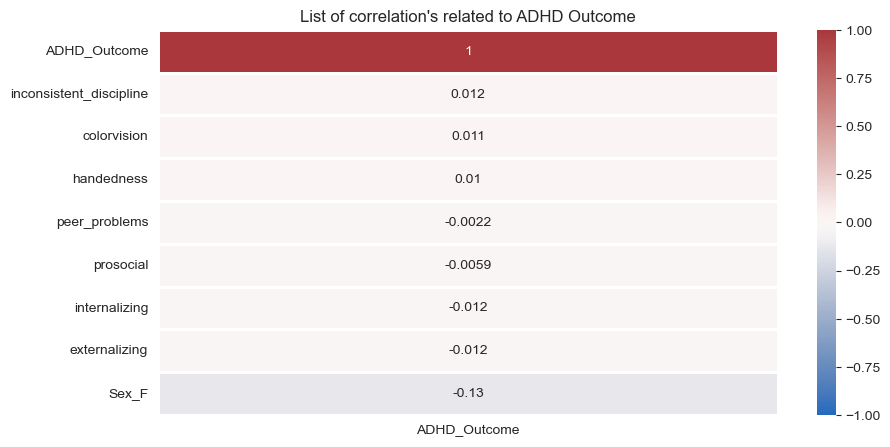

In [244]:
corr_matrix = pd.concat([adhd_qm_df, y], axis=1).corr(method = 'kendall')

fig, ax = plt.subplots(figsize = (10, 5))
sns.set_style("whitegrid")
heat = sns.heatmap(corr_matrix[["ADHD_Outcome"]].sort_values(by='ADHD_Outcome', ascending=False), linewidth=1,annot=True, cmap = 'vlag', vmin=-1)
plt.title("List of correlation's related to ADHD Outcome")
plt.show()

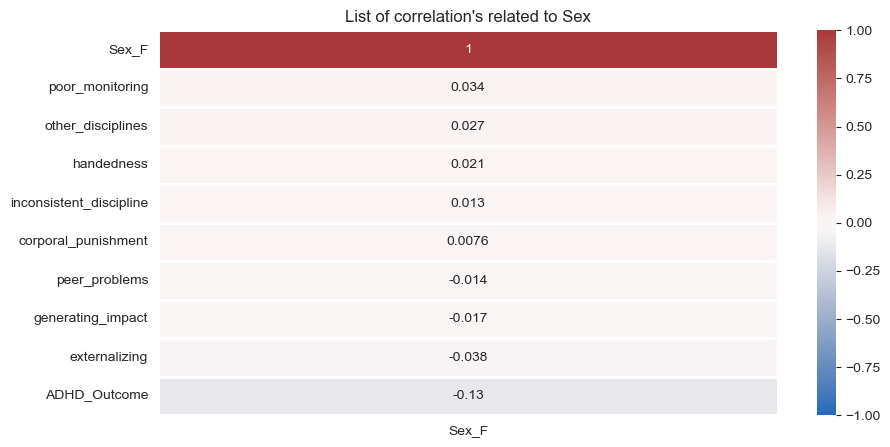

In [245]:
corr_matrix = pd.concat([sex_qm_df, y], axis=1).corr(method = 'kendall')

fig, ax = plt.subplots( figsize = (10, 5))
sns.set_style("whitegrid")
heat = sns.heatmap(corr_matrix[["Sex_F"]].sort_values(by='Sex_F', ascending=False), linewidth=1,annot=True, cmap = 'vlag', vmin=-1)
plt.title("List of correlation's related to Sex")
plt.show()

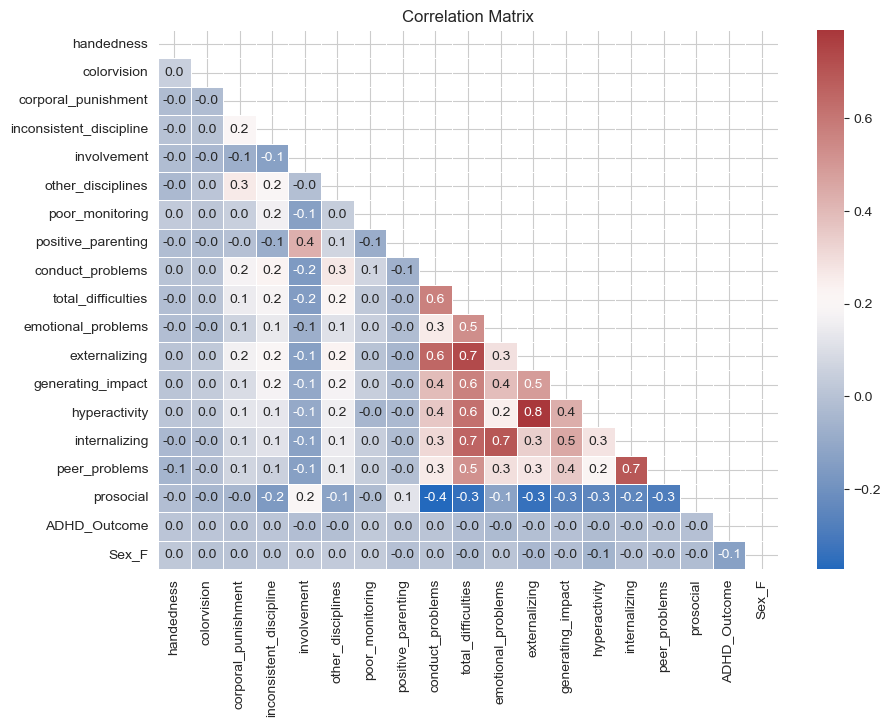

In [248]:
corr_matrix = pd.concat([qm_df, y], axis=1).corr(method = 'kendall')


fig, ax = plt.subplots( figsize = (10, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='vlag', fmt=".1f", linewidths= .5)
plt.title('Correlation Matrix')
plt.show()

#### Conclusion

It's hard to parse these correlations with our target variables. For some reason there is little to no information being teased out here.
So we will rely on our feature selection via mutual info.

### Dendrogram

{1: '#ffff33', 0: '#984ea3'}


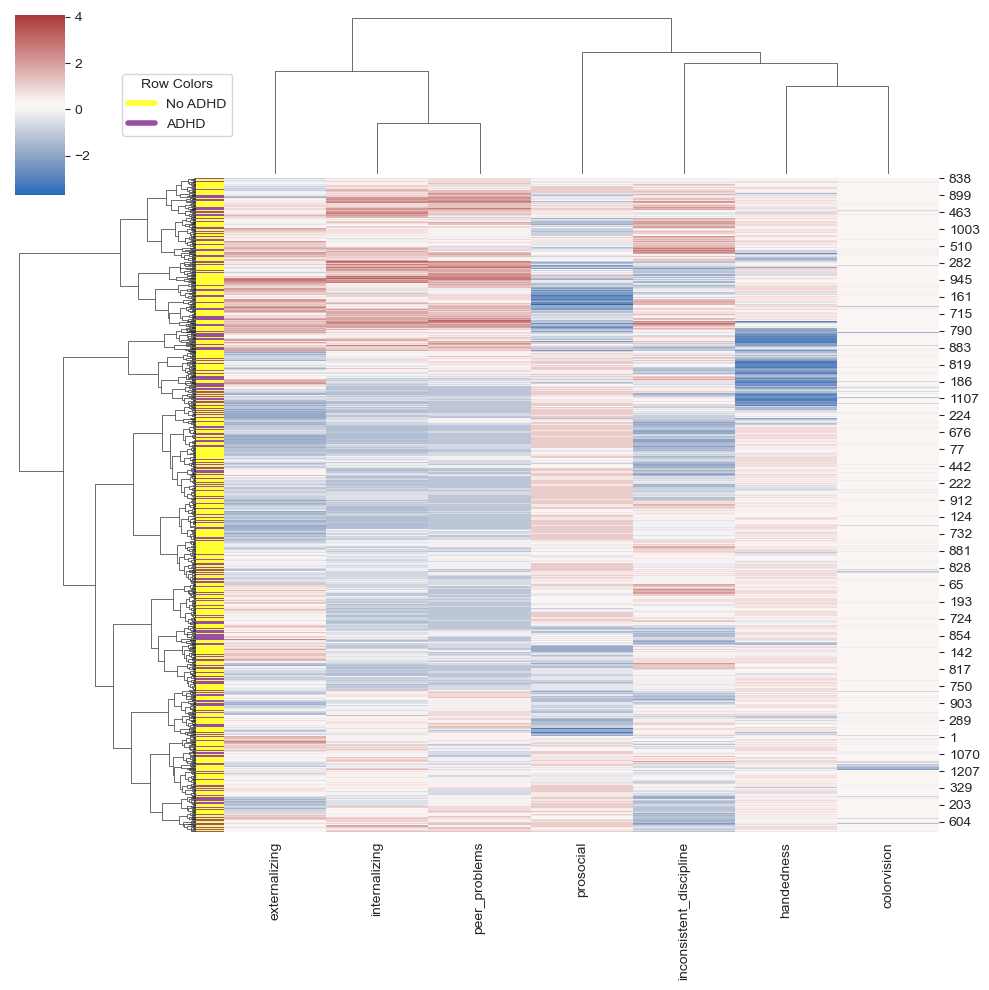

In [270]:
color_array = ["#ffff33","#984ea3"]
# the color for the labels
lut = dict(zip(y["ADHD_Outcome"].unique(), color_array))
print(lut)
row_colors = y["ADHD_Outcome"].map(lut)

sns.clustermap(adhd_qm_df, method="ward", metric="euclidean",row_colors=row_colors.to_numpy(), cmap="vlag")


plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="No ADHD"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="ADHD")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)
)

{1: '#ffff33', 0: '#984ea3'}


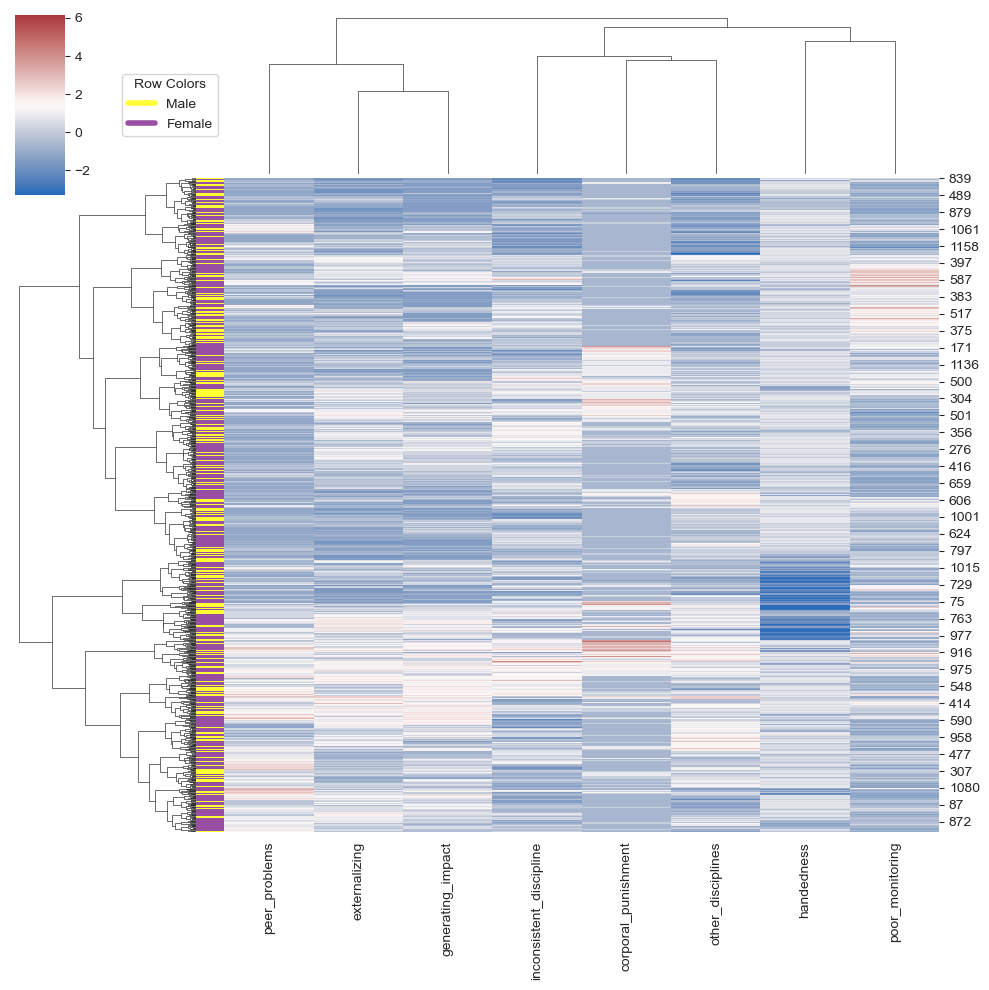

In [271]:
color_array = ["#ffff33","#984ea3"]
# the color for the labels
lut = dict(zip(y["Sex_F"].unique(), color_array))
print(lut)
row_colors = y["Sex_F"].map(lut)

sns.clustermap(sex_qm_df, method="ward", metric="euclidean",row_colors=row_colors.to_numpy(), cmap="vlag")


plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="Male"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="Female")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)  # Position the legend outside the plot
)


#### Conclusion

From above, we can begin to see that we may be able to reduce our features down to possibly 2-3 clusters. Further, it seems easier to parse sex from this data, then it is to parse ADHD.

### Conclusion in Quantative exploration
Moving forward we will be working with the dataframes made above: sex_qm_df and adhd_qm_df

## Categorical

### Initial Feature Drop
For useless feature

In [207]:
if "enroll_year" in cm_df.columns:
    cm_df = cm_df.drop(columns=['enroll_year'])


### Feature selection via mutual info
We will be applying the same method from above.

In [252]:
mi_scores = mutual_info_classif(cm_df, y["ADHD_Outcome"])

mutual_info_dict = dict(zip(cm_df.columns, mi_scores))

selected_features = [feature for feature, score in mutual_info_dict.items() if score > 0]

adhd_cm_df = cm_df[selected_features]

print(adhd_cm_df.shape)
print(adhd_cm_df.head())

(1120, 29)
   study_site_Staten Island  ethnicity_Decline to specify  race_Asian  \
0                     False                         False       False   
1                      True                         False       False   
2                      True                         False       False   
3                      True                         False       False   
4                      True                         False       False   

   race_Choose not to specify  race_Hispanic  race_Other race  \
0                       False          False            False   
1                       False          False             True   
2                       False           True            False   
3                       False          False            False   
4                       False          False            False   

   race_Two or more races  race_White/Caucasian  scan_site_CBIC  \
0                   False                  True            True   
1                   False

In [253]:
mi_scores = mutual_info_classif(cm_df, y["Sex_F"])

mutual_info_dict = dict(zip(cm_df.columns, mi_scores))

selected_features = [feature for feature, score in mutual_info_dict.items() if score > 0]

sex_cm_df = cm_df[selected_features]

print(sex_cm_df.shape)
print(sex_cm_df.head())

(1120, 30)
   ethnicity_Unknown  race_Black/African American  race_Choose not to specify  \
0              False                        False                       False   
1              False                        False                       False   
2              False                        False                       False   
3               True                        False                       False   
4              False                         True                       False   

   race_Native Hawaiian/Other Pacific Islander  race_Other race  race_Unknown  \
0                                        False            False         False   
1                                        False             True         False   
2                                        False            False         False   
3                                        False            False         False   
4                                        False            False         False   

   race_White/C

### Correlation

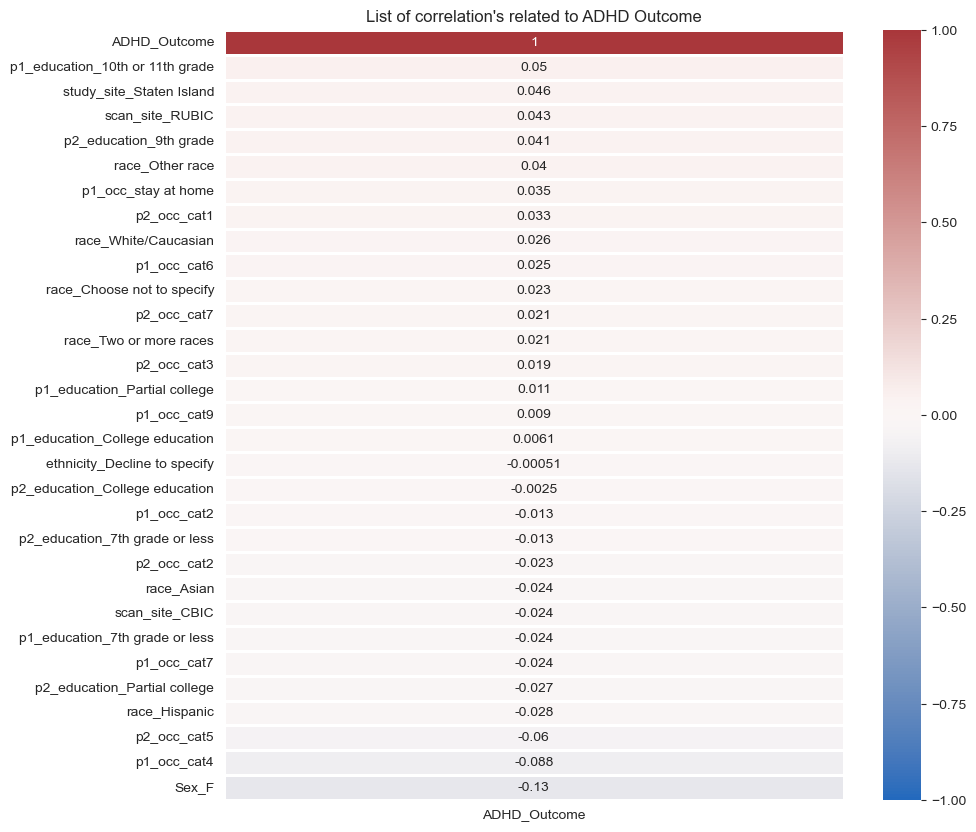

In [255]:
corr_matrix = pd.concat([adhd_cm_df, y], axis=1).corr()

fig, ax = plt.subplots(figsize = (10, 10))
sns.set_style("whitegrid")
heat = sns.heatmap(corr_matrix[["ADHD_Outcome"]].sort_values(by='ADHD_Outcome', ascending=False), linewidth=1,annot=True, cmap = 'vlag', vmin=-1)
plt.title("List of correlation's related to ADHD Outcome")
plt.show()

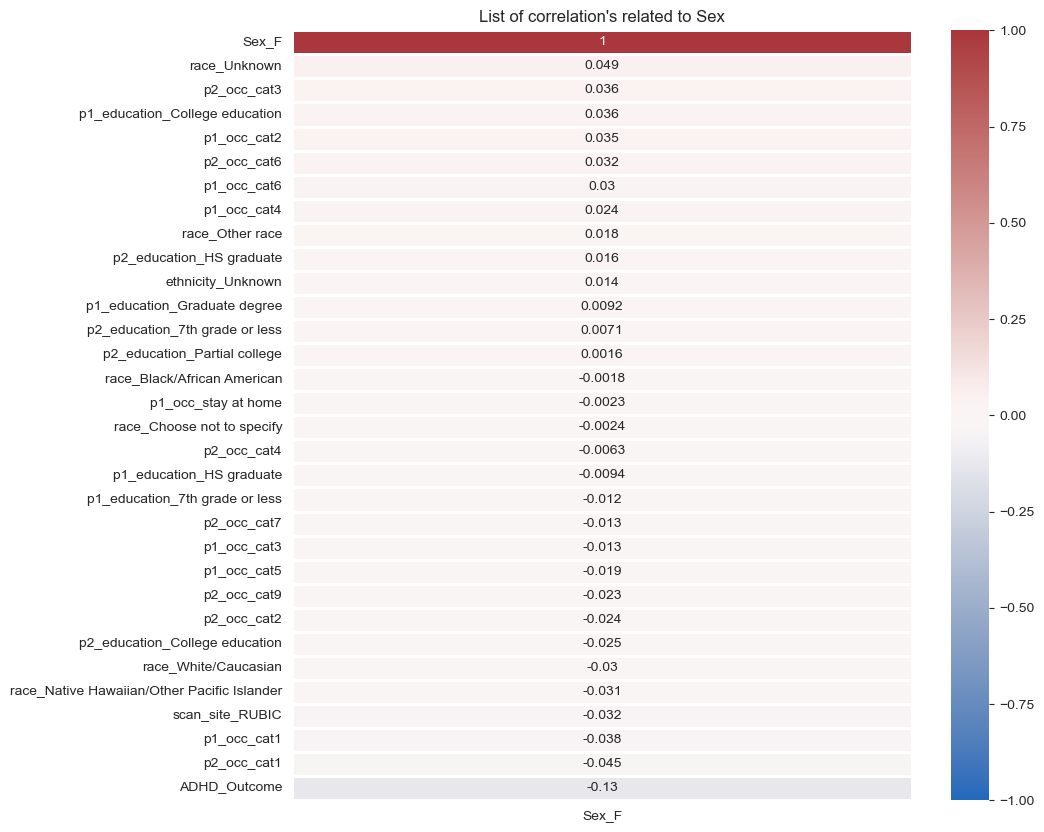

In [257]:
corr_matrix = pd.concat([sex_cm_df, y], axis=1).corr()

fig, ax = plt.subplots( figsize = (10, 10))
sns.set_style("whitegrid")
heat = sns.heatmap(corr_matrix[["Sex_F"]].sort_values(by='Sex_F', ascending=False), linewidth=1,annot=True, cmap = 'vlag', vmin=-1)
plt.title("List of correlation's related to Sex")
plt.show()

#### Conclusion
Again, its a little hard to tease out information from these graphs.

### Dendrograms

{1: '#ffff33', 0: '#984ea3'}


C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


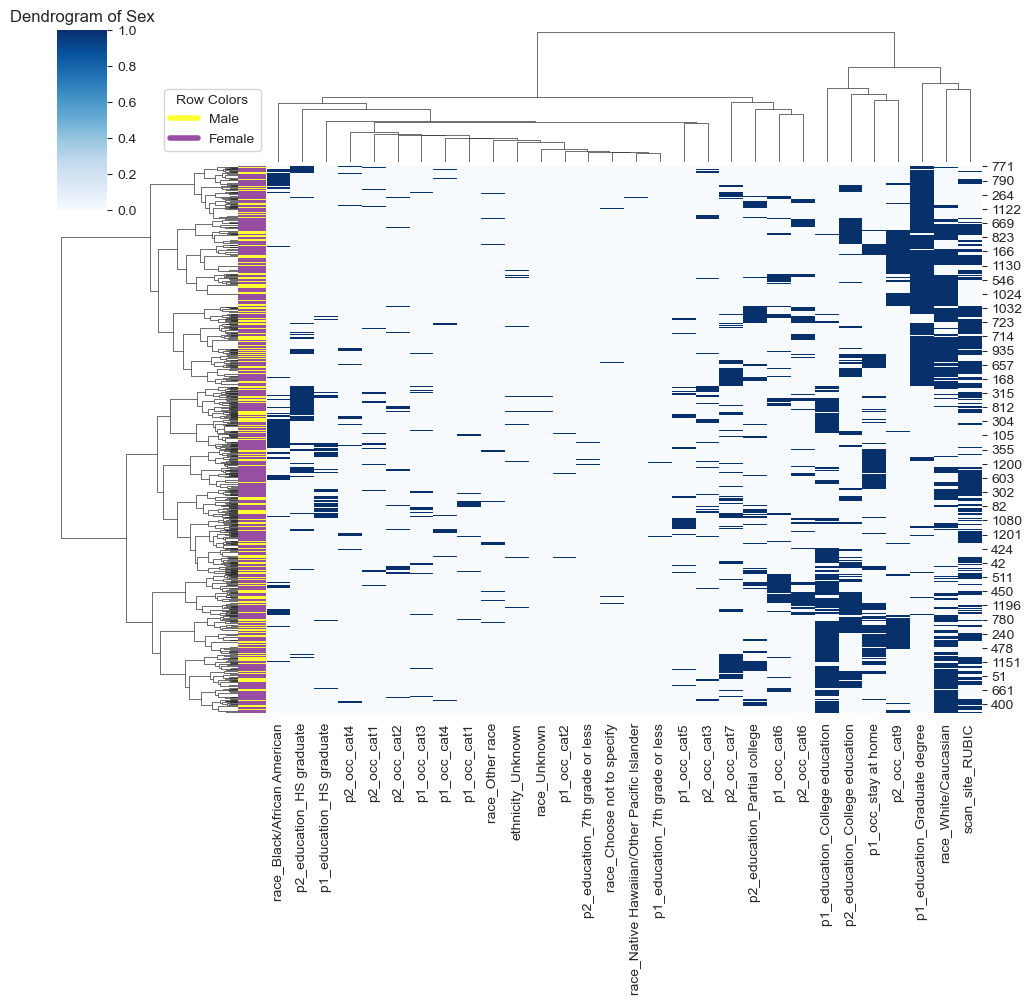

In [263]:
color_array = ["#ffff33","#984ea3"]
#"#984ea3","#a65628",
# the color for the labels
lut = dict(zip(y["Sex_F"].unique(), color_array))
print(lut)
row_colors = y["Sex_F"].map(lut)

sns.clustermap(
    sex_cm_df,
    method="ward",
    metric="euclidean",
    cmap="Blues",
    row_colors=row_colors.to_numpy(),
)


plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="Male"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="Female")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)  # Position the legend outside the plot
)

plt.title("Dendrogram of Sex")
plt.show()

{1: '#ffff33', 0: '#984ea3'}


C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


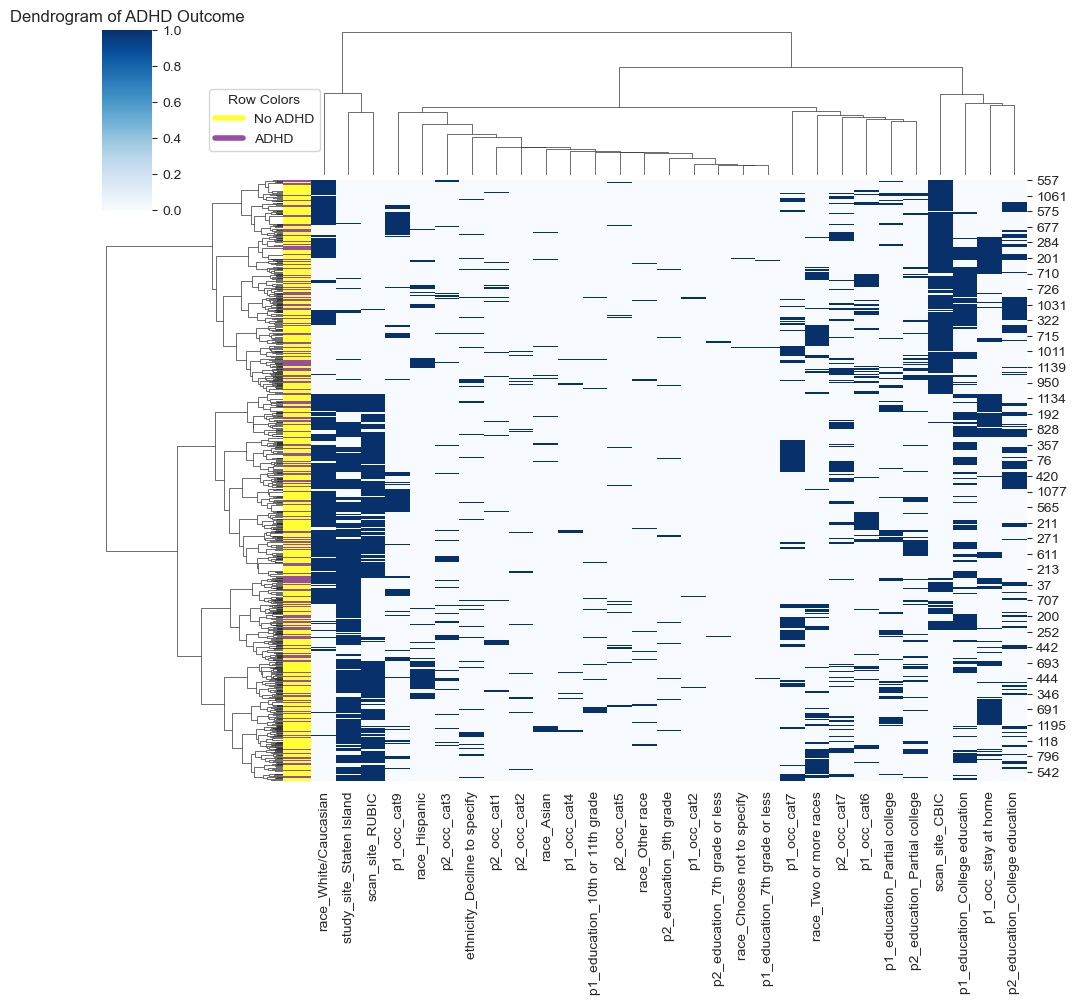

In [262]:
color_array = ["#ffff33","#984ea3"]
#"#984ea3","#a65628",
# the color for the labels
lut = dict(zip(y["ADHD_Outcome"].unique(), color_array))
print(lut)
row_colors = y["ADHD_Outcome"].map(lut)

sns.clustermap(
    adhd_cm_df,
    method="ward",
    metric="euclidean",
    cmap="Blues",
    row_colors=row_colors.to_numpy(),
)


plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="No ADHD"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="ADHD")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)  # Position the legend outside the plot
)

plt.title("Dendrogram of ADHD Outcome")
plt.show()

#### Conclusion
We can somewhat see tiny clusters arising from the row colors (yellow/purple) of both our histograms.

## FMRI

### Single connectome example

<Axes: >

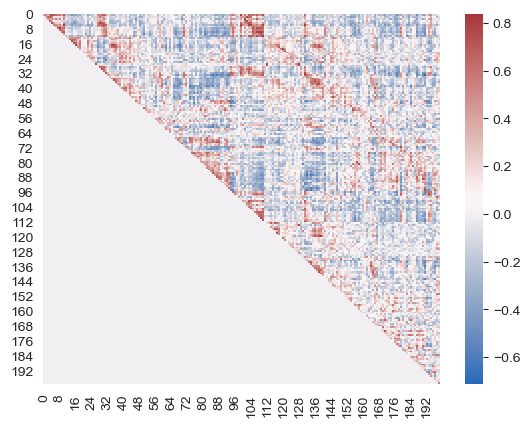

In [269]:
sns.heatmap(fcm_3d_df[867], cmap="vlag")

C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


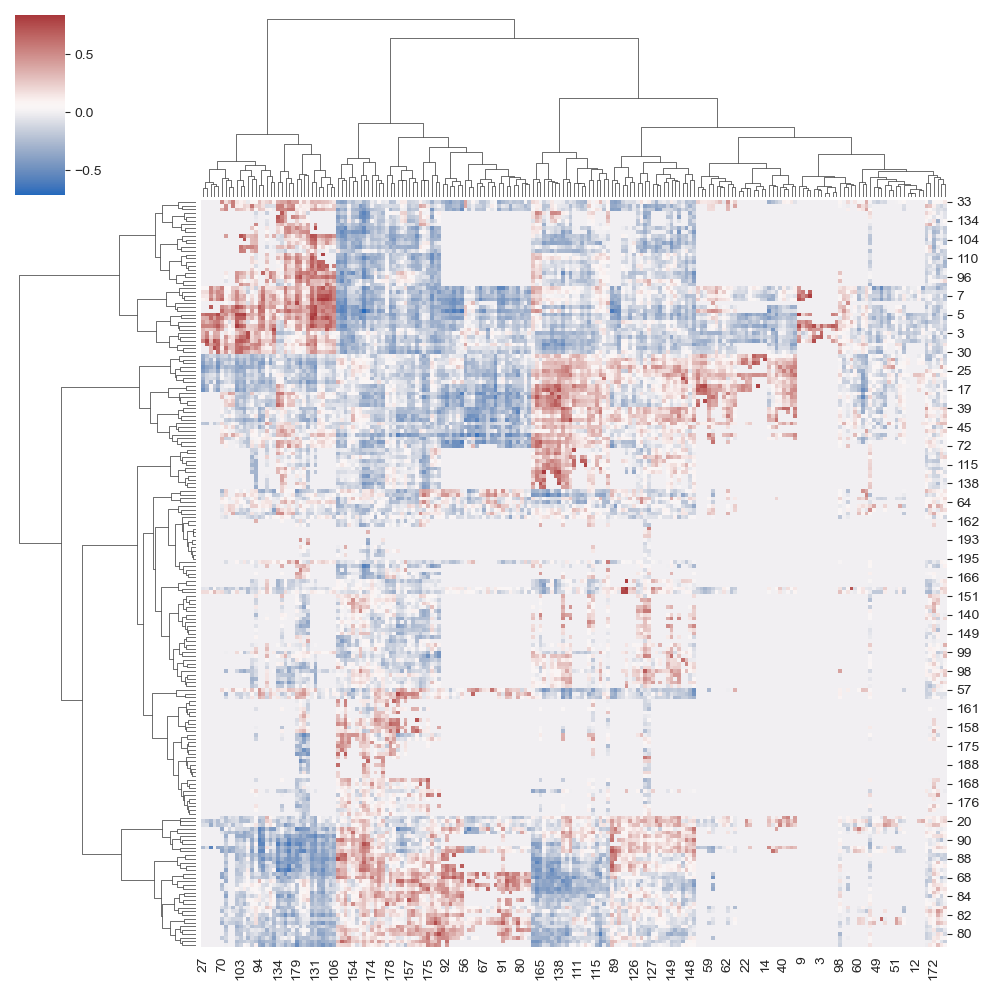

In [272]:
sns.clustermap(fcm_3d_df[867], method="ward", metric="euclidean", cmap="vlag")

It may be viable to cluster this data via 10x15. The following process details this.

### Clustering

In [294]:
#Hierarchical clustering of a single connectome
linkage_matrix = linkage(fcm_3d_df[0], method='ward', metric='euclidean')
clusters = fcluster(linkage_matrix, 10, criterion='maxclust')
print("Clusters found:", clusters)



Clusters found: [ 5  4  5  4  2  5  5  5  5  5  5  5  1  1  1  1  1  1  1  1  7  7  6  6
  7  7  6  6  9  3  2  2  2  3  1  1  1  3  2  7  7  7  7  2  9  7  3  9
  7  9  2  2  6 10 10 10  2  3  3  3  2  3  8  3  8  9  9  3  8  4  4 10
  2 10  8  8  8  8 10  2  2  8  8  8  8  6  8  8  8  8 10  2  2 10  8  8
  8  8  6  8  6  4  4  4  4 10  6  6  6  6  7  7  4  7  7  7  4  4  4  4
  4  4  4  7  7  7  7 10 10 10  9 10 10  4  4  4 10 10  4  4 10  9  9 10
 10  9  9  9  9  9  9  9  9  9  9 10  4  4 10 10 10 10 10 10 10  4  4 10
 10 10 10 10 10  4 10 10  4 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10]


In [295]:
def within_cluster_connectivity(matrix, cluster_labels):
    cluster_ids = np.unique(cluster_labels)
    features = []
    for cluster in cluster_ids: #for each cluster, find the mean of its edges
        mask = cluster_labels == cluster
        sub_matrix = matrix[mask][:, mask]
        mean_connectivity = np.mean(sub_matrix)
        features.append(mean_connectivity)
    return features

print(within_cluster_connectivity(fcm_3d_df[0], clusters))

[0.2247259252342807, 0.06919453421089508, 0.05838199444690503, 0.06129879673870118, 0.1678742449405717, 0.1299625013530547, 0.10601584284282639, 0.12892870416416316, 0.13903763369507902, 0.056770176103886225]


In [296]:
def between_cluster_connectivity(matrix, cluster_labels): #find connectivity between all clusters
    cluster_ids = np.unique(cluster_labels)
    features = []
    for i, cluster_i in enumerate(cluster_ids): #cluster 1
        for j, cluster_j in enumerate(cluster_ids): #cluster2
            if i >= j:
                continue
            mask_i = cluster_labels == cluster_i #select only relevant cluster
            mask_j = cluster_labels == cluster_j #select only relevant cluster
            sub_matrix = matrix[mask_i][:, mask_j] #define roi
            mean_connectivity = np.mean(sub_matrix)
            features.append(mean_connectivity)
    return features

print(between_cluster_connectivity(fcm_3d_df[0], clusters))

[-0.005597027823609793, 0.08243341206482419, 0.06782371137229044, 0.0, -0.06649906924377029, 0.0514815038564961, -0.025655712502420425, -0.009024164773908333, -0.06714771128787769, 0.04542835481700291, 0.01660273921954017, -0.005690197424458864, -0.08666542190269651, -0.08339269263408892, -0.019995737336459662, 0.03783979127819171, -0.009687070453588744, 0.14158164773207196, 0.0, -0.062367227884058414, 0.020899131549398094, -0.08897197641326851, 0.1076034137436603, -0.00774954380417232, -0.006275796539373998, -0.015334218388909016, -0.00523966004929373, -0.004219140641815865, -0.0059661961213017594, -0.047831971490257544, 0.21699775057519866, 0.08009979763881499, 0.000499022920210685, -0.0071525471055261846, 0.027235619249469236, 0.09764255484457621, 0.051078263435085654, -0.006429323587671923, 0.05129729979054647, 0.00016994134056185685, 0.08638936107647534, 0.01666551097121099, -0.008578200471178712, 0.06160340567645805, 0.03977128605691103]


In [297]:
all_features = []

#apply both functions above to each all rows in our fcm_3d_df
for i in range(fcm_3d_df.shape[0]):
    #for each matrix, get a hierarchical cluster mapping
    connectome = fcm_3d_df[i]
    linkage_matrix = linkage(connectome, method='ward', metric='euclidean')
    clusters = fcluster(linkage_matrix, 10, criterion='maxclust')

    #compute cluster features
    within_features = within_cluster_connectivity(connectome, clusters)
    between_features = between_cluster_connectivity(connectome, clusters)

    #for all clusters append corresponding feature computation and add to features for the row
    features = {f'Within_Cluster_{i+1}_Connectivity':
                           within_features[i] if i < len(within_features) else None
                           for i in range(10)
    }
    features.update({f'Between_Cluster_{i+1}_Connectivity':
                                between_features[i] if i < len(between_features) else None
                                for i in range(len(between_features))})
    #add to master featurelist
    all_features.append(features)

fcm_cluster_features = pd.DataFrame(all_features)

print(fcm_cluster_features.head())
print(fcm_cluster_features.shape)

   Within_Cluster_1_Connectivity  Within_Cluster_2_Connectivity  \
0                       0.224726                       0.069195   
1                       0.153727                       0.166494   
2                       0.125478                       0.243027   
3                       0.066268                       0.222229   
4                       0.182750                       0.188648   

   Within_Cluster_3_Connectivity  Within_Cluster_4_Connectivity  \
0                       0.058382                       0.061299   
1                       0.095553                       0.121001   
2                       0.256498                       0.234043   
3                       0.224305                       0.074182   
4                       0.111556                       0.137909   

   Within_Cluster_5_Connectivity  Within_Cluster_6_Connectivity  \
0                       0.167874                       0.129963   
1                       0.144971                       0.109

### PCA extraction

In [316]:
fcm_pca_df = PCA(n_components = 10).fit_transform(fcm_df)

fcm_pca_df = pd.DataFrame(data=fcm_pca_df, index=fcm_df.index)

print(fcm_pca_df.head())

          0         1         2         3         4         5         6  \
0 -0.588467  0.005680 -0.031842  0.219909  0.038228 -0.227702 -0.231023   
1 -1.016373 -0.148387  0.234604  0.178687  0.391295  0.226403  0.354524   
2  0.201244  0.801834  0.686644  0.364776  0.527995 -0.294177 -0.149521   
3  0.774086 -0.348100 -0.285959  0.349051 -0.248300 -0.039382 -0.268423   
4 -0.093151 -0.626107  0.113697  0.434047  0.099455 -0.030806  0.488567   

          7         8         9  
0 -0.013338 -0.174720 -0.627766  
1  0.450681 -0.308531 -0.153546  
2  0.414301 -0.199991 -0.133815  
3  0.230947  0.141847 -0.260681  
4  0.003286  0.214667 -0.375831  


### Dendrograms for all of our extracted features

{1: '#ffff33', 0: '#984ea3'}


C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(0.5, 1.0, 'Dendrogram of ADHD Outcome')

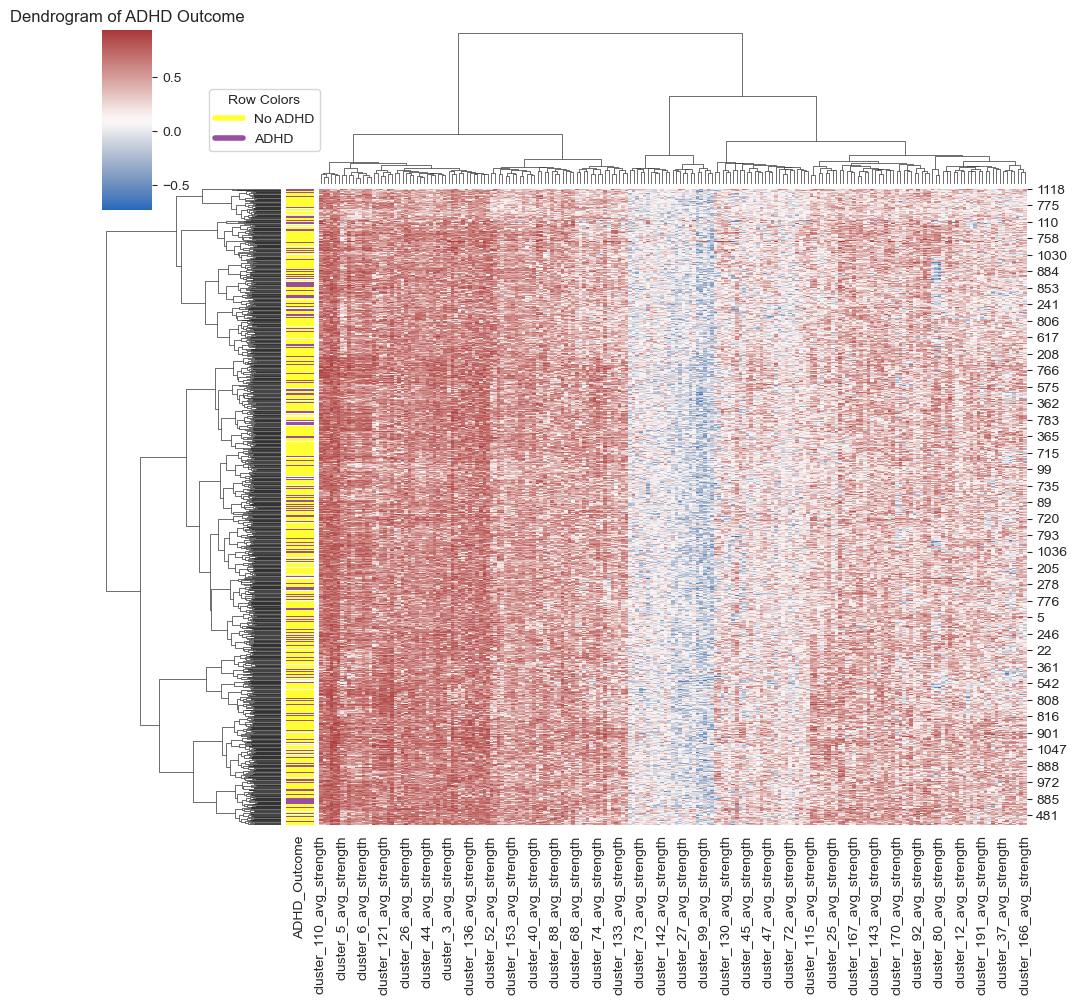

In [305]:
color_array = ["#ffff33","#984ea3"]

# the color for the labels
lut = dict(zip(y["ADHD_Outcome"].unique(), color_array))
print(lut)
row_colors = y["ADHD_Outcome"].map(lut)


sns.clustermap(fcm_df, method="ward", metric="euclidean", row_colors=row_colors, cmap="vlag")

plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="No ADHD"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="ADHD")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)  # Position the legend outside the plot
)

plt.title("Dendrogram of ADHD Outcome")

{1: '#ffff33', 0: '#984ea3'}


C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(0.5, 1.0, 'Dendrogram of Sex Outcome')

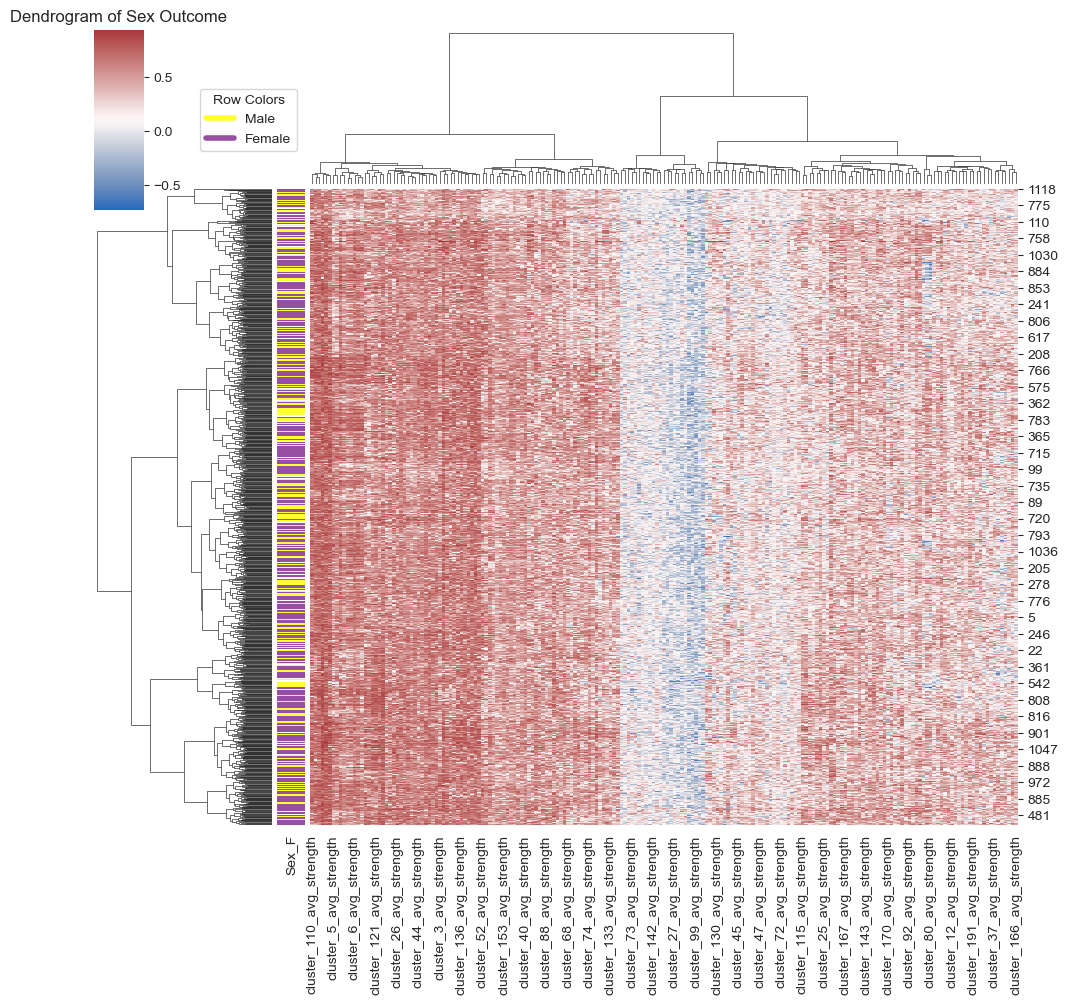

In [306]:
color_array = ["#ffff33","#984ea3"]

# the color for the labels
lut = dict(zip(y["Sex_F"].unique(), color_array))
print(lut)
row_colors = y["Sex_F"].map(lut)


sns.clustermap(fcm_df, method="ward", metric="euclidean", row_colors=row_colors, cmap="vlag")

plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="Male"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="Female")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)  # Position the legend outside the plot
)

plt.title("Dendrogram of Sex Outcome")

### Dendrogram for cluster connectivity features

{1: '#ffff33', 0: '#984ea3'}


C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(0.5, 1.0, 'Dendrogram of ADHD Outcome')

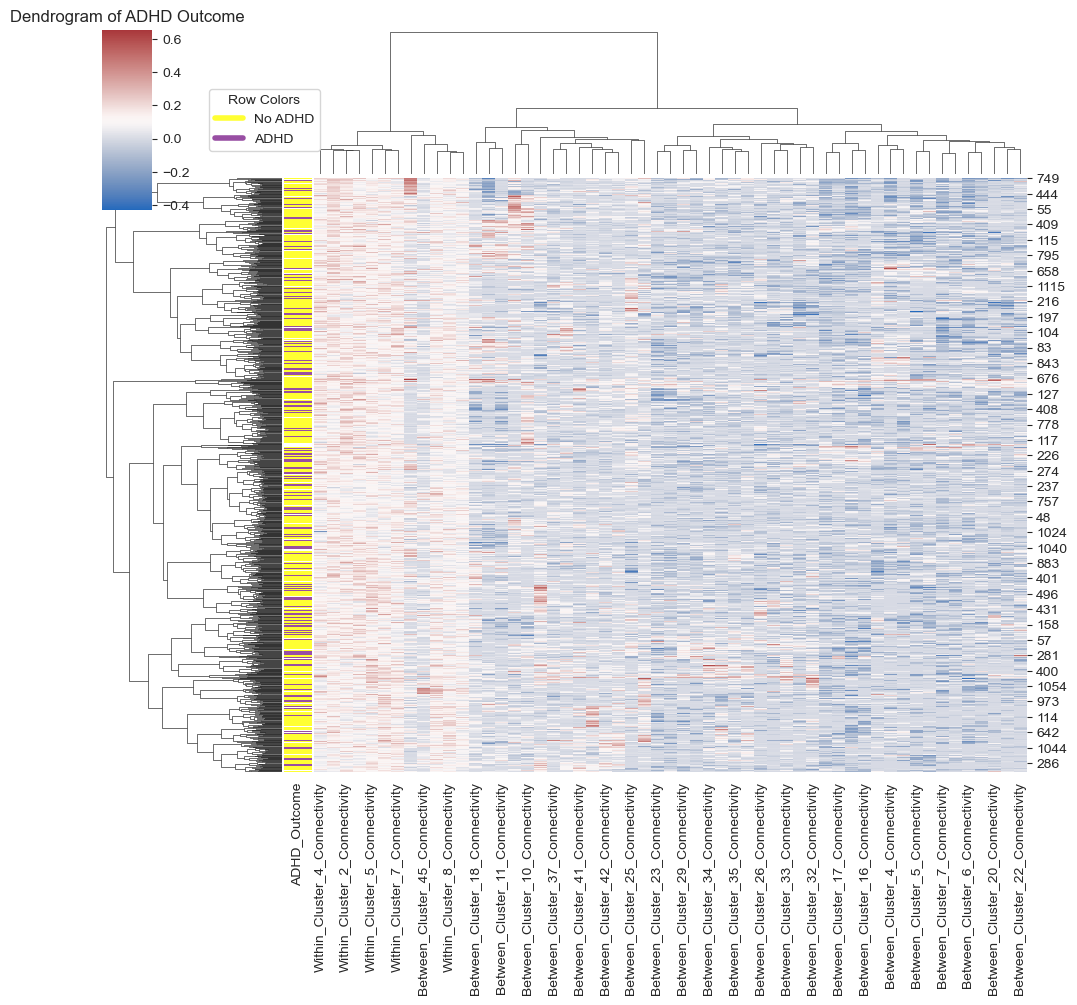

In [307]:
color_array = ["#ffff33","#984ea3"]

# the color for the labels
lut = dict(zip(y["ADHD_Outcome"].unique(), color_array))
print(lut)
row_colors = y["ADHD_Outcome"].map(lut)


sns.clustermap(fcm_cluster_features, method="ward", metric="euclidean", row_colors=row_colors, cmap="vlag")

plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="No ADHD"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="ADHD")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)  # Position the legend outside the plot
)

plt.title("Dendrogram of ADHD Outcome")

{1: '#ffff33', 0: '#984ea3'}


C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(0.5, 1.0, 'Dendrogram of Sex Outcome')

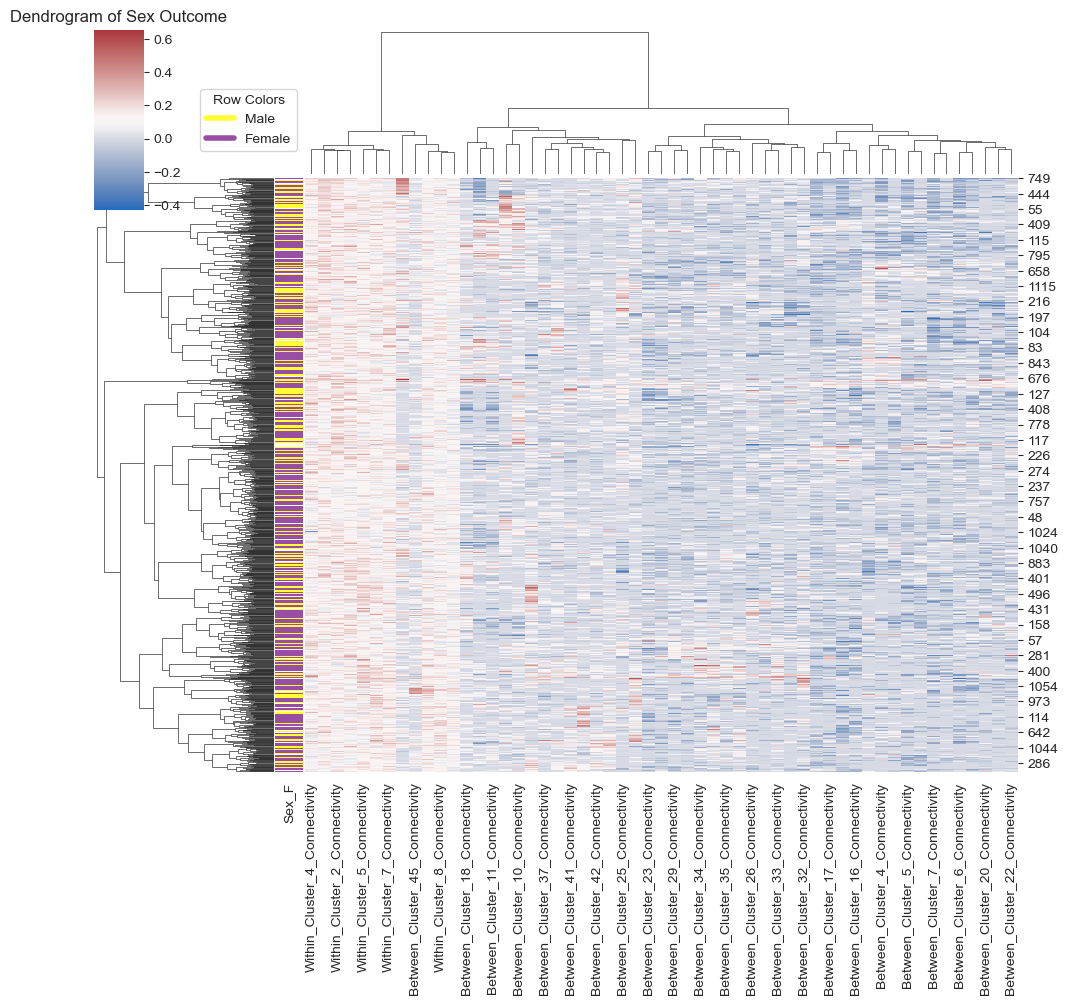

In [308]:
color_array = ["#ffff33","#984ea3"]

# the color for the labels
lut = dict(zip(y["Sex_F"].unique(), color_array))
print(lut)
row_colors = y["Sex_F"].map(lut)


sns.clustermap(fcm_cluster_features, method="ward", metric="euclidean", row_colors=row_colors, cmap="vlag")

plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="Male"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="Female")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)  # Position the legend outside the plot
)

plt.title("Dendrogram of Sex Outcome")

### PCA Dendrograms

{1: '#ffff33', 0: '#984ea3'}


C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(0.5, 1.0, 'Dendrogram of ADHD Outcome')

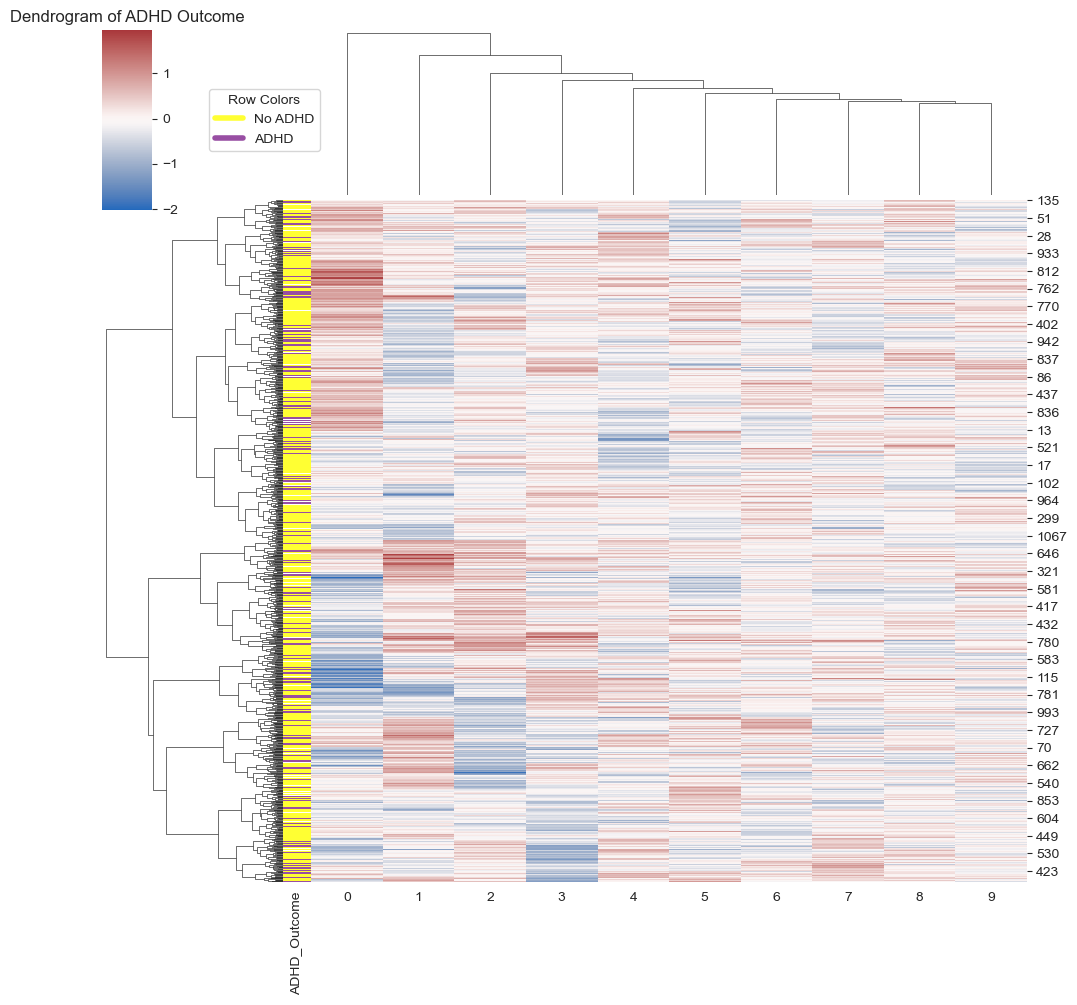

In [317]:
color_array = ["#ffff33","#984ea3"]

# the color for the labels
lut = dict(zip(y["ADHD_Outcome"].unique(), color_array))
print(lut)
row_colors = y["ADHD_Outcome"].map(lut)


sns.clustermap(fcm_pca_df, method="ward", metric="euclidean", row_colors=row_colors, cmap="vlag")

plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="No ADHD"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="ADHD")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)  # Position the legend outside the plot
)

plt.title("Dendrogram of ADHD Outcome")

{1: '#ffff33', 0: '#984ea3'}


C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\patri\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Text(0.5, 1.0, 'Dendrogram of Sex Outcome')

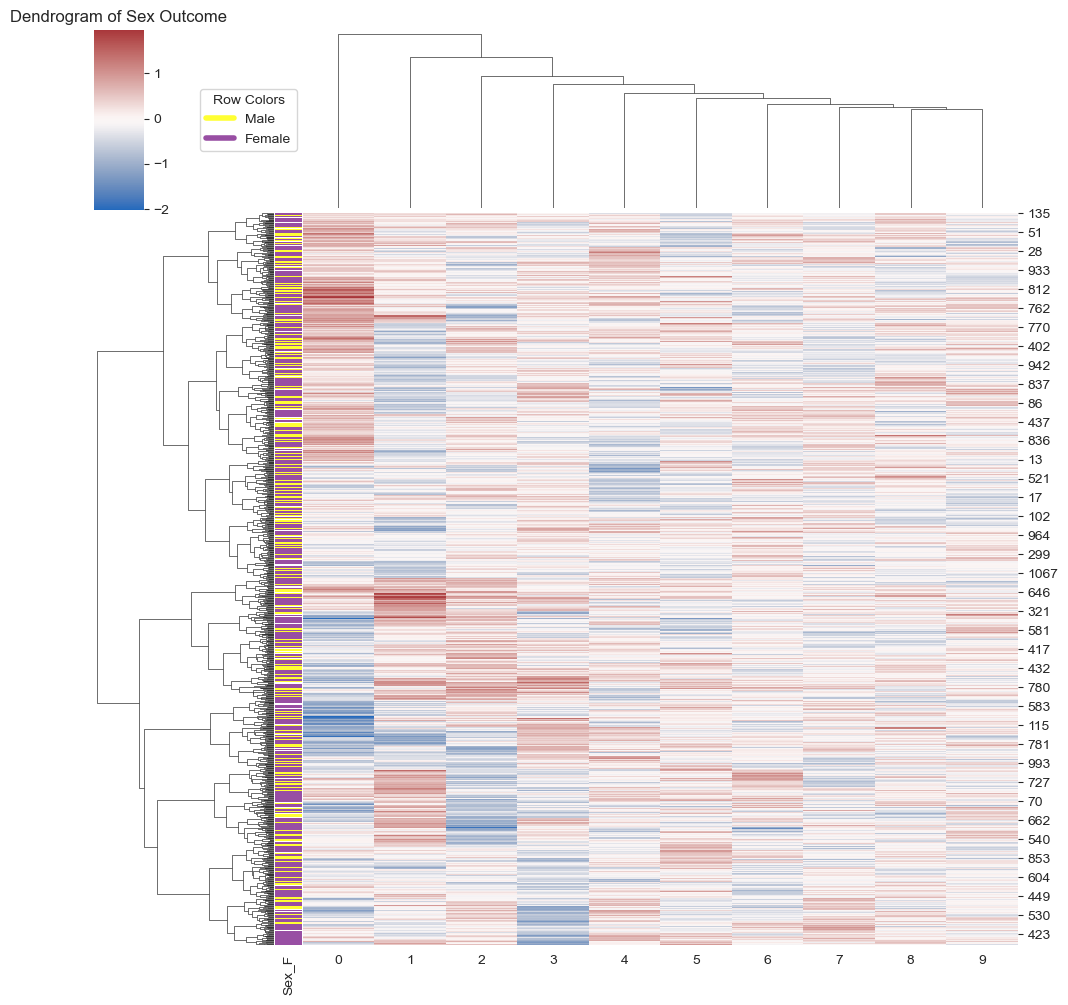

In [318]:
color_array = ["#ffff33","#984ea3"]

# the color for the labels
lut = dict(zip(y["Sex_F"].unique(), color_array))
print(lut)
row_colors = y["Sex_F"].map(lut)


sns.clustermap(fcm_pca_df, method="ward", metric="euclidean", row_colors=row_colors, cmap="vlag")

plt.legend(
    handles=[
        plt.Line2D([0], [0], color="#ffff33", lw=4, label="Male"),
        plt.Line2D([0], [0], color="#984ea3", lw=4, label="Female")
    ],
    title="Row Colors",
    loc="center left",
    bbox_to_anchor=(2, 0.5)  # Position the legend outside the plot
)

plt.title("Dendrogram of Sex Outcome")

### Conclusion

SThese three dendrograms are as follows:
<br>
<br>
The first two dendrograms describe the information extracted from the communities via networkx, and their corresponding strength. We can observe that its hard to tease out clusters of ADHD_outcome.
<br>
<br>
The following 2 dendrograms are respectively Sex and ADHD outcome as it relates to our latest feature extract based off of hierarchical clusters and their properties of our connectome matrices.
<br>
<br>
The last 2 dendrograms are respectively Sex and ADHD outcome as it relates to PCA data extracted from our original FMRI dataframe.
<br>
<br>
All three methods seem somewhat the same in terms of clustering our targets together. However, we will be moving forward with our first dataframe of features, the strength of communities.

# Analysis Methodology

## Results

Candidate classification models were evaluated for accuracy and bias. 

Three distinct dataframes were tested using the strongest candidate model (SVM): 
1. fMRI connectome data subsetted for the 1000 edges with the greatest effect size between outcome factors.
2. fMRI connectome data with variables decomposed by PCA (1000 components)
3. fMRI connectome data with variables decomposed by strength of communities

Here we analyze the fMRI connectome edges and extract the 1000 edges with the largest effect size for each sex and ADHD outcome variables.

In [ ]:
## TRAINING DATA

# Read data and combine outcome variables with fMRI data
connect_df = pd.read_csv('widsdatathon2025/TRAIN_NEW/Train_Connectome.csv')
factors_df = pd.read_excel('widsdatathon2025/TRAIN_NEW/Train_Outcome.xlsx')
combined_df = pd.concat([connect_df, factors_df], axis=1)

print(connect_df.shape)
print(factors_df.shape)
print(list(factors_df.columns))
print(combined_df.shape)

# Drop ID column
combined_df.drop(columns=['participant_id'], inplace=True)
print(combined_df.shape)

In [ ]:
## Sex section

# Split dataframe by sex
sex_f = combined_df[combined_df['Sex_F'] == 1]
sex_m = combined_df[combined_df['Sex_F'] == 0]

# Calculate means for each feature
f_means = sex_f.mean()
m_means = sex_m.mean()

# Calculate difference between means and sort
sex_delta = pd.Series(abs(f_means - m_means))
sex_sorted = sex_delta.sort_values(ascending=False)
sex_hist = sex_sorted.drop(['Sex_F', 'ADHD_Outcome'])

In [ ]:
# Plot histogram of effect sizes
plt.hist(sex_hist, density=False, bins=20) 
plt.ylabel('Count')
plt.xlabel('Delta')
plt.title('Histogram of edge mean differences ~ Sex')
plt.show()

#!# Effect size comment here

In [ ]:
# Retrieve index values for 1000 strongest edges 
sex_delta = sex_delta.drop(['Sex_F', 'ADHD_Outcome'])
sex_top_n = sex_delta.nlargest(n=1000, keep='all')
sex_n_edges = list(sex_top_n.index)
print(sex_top_n)

# Slice dataframe by strongest 1000 edges
topn_edges_sex_train = combined_df.loc[:, sex_n_edges]

In [ ]:
# Here we perform a t-test on each selected variable and plot the results to evaluate significance

# Split dataframe by sex
sex_f = pd.DataFrame(topn_edges_sex_train[topn_edges_sex_train['Sex_F'] == 1])
sex_m = pd.DataFrame(topn_edges_sex_train[topn_edges_sex_train['Sex_F'] == 0])

t_tst_pvals = []

# Compare stats for each feature
for i in range(1, len(sex_f.columns)):
    result = stats.ttest_ind(a = sex_f.iloc[:,i], b = sex_m.iloc[:,i], equal_var=True)
    t_tst_pvals.append(result.pvalue)


In [ ]:
# Plot histogram
fig, ax = plt.subplots(1, 1)
bins = np.arange(0,0.25,0.025)
# Adjust the border color
ax.hist(t_tst_pvals, bins, edgecolor="black")

ax.set_title('Histogram of p-values for edge strengths ~ Sex')
ax.set_xlabel('p-value')
ax.set_ylabel('Count')
plt.show()

#!# p-val comment here

In [ ]:
## ADHD Section

# Split dataframe by ADHD status
adhd_pos = combined_df[combined_df['ADHD_Outcome'] == 1]
adhd_neg = combined_df[combined_df['ADHD_Outcome'] == 0]

# Calculate means for each feature
pos_means = adhd_pos.mean()
neg_means = adhd_neg.mean()

# Calculate difference between means and sort
adhd_delta = abs(pos_means - neg_means)
adhd_sorted = adhd_delta.sort_values(ascending=False)
adhd_hist = adhd_sorted.drop(['Sex_F', 'ADHD_Outcome'])

In [ ]:
# Plot histogram of deltas
plt.hist(adhd_hist, density=False, bins=20) 
plt.ylabel('Count')
plt.xlabel('Delta')
plt.title('Histogram of edge mean differences ~ ADHD')
plt.show()

#!# Effect size comment here

In [ ]:
# Retrieve index values for 1000 strongest edges 
adhd_delta = adhd_delta.drop(['Sex_F', 'ADHD_Outcome'])
adhd_top_n = adhd_delta.nlargest(n=1000, keep='all')
adhd_n_edges = list(adhd_top_n.index)
print(adhd_top_n)
# Slice dataframe by strongest 1000 edges
topn_edges_adhd_train = combined_df.loc[:, adhd_n_edges]


In [ ]:
# Here we perform a t-test on each selected variable and plot the results to evaluate significance

# Split dataframe by ADHD status
adhd_pos = pd.DataFrame(topn_edges_adhd_train[topn_edges_adhd_train['ADHD_Outcome'] == 1])
adhd_neg = pd.DataFrame(topn_edges_adhd_train[topn_edges_adhd_train['ADHD_Outcome'] == 0])

# Compare stats for each feature
t_tst_pvals_A = []
for i in range(1, len(adhd_pos.columns)):
    result_A = stats.ttest_ind(a = adhd_pos.iloc[:,i], b = adhd_neg.iloc[:,i], equal_var=True)
    t_tst_pvals_A.append(result_A.pvalue)


#!# p-val comment here

In [ ]:
# Plot histogram
fig, ax = plt.subplots(1, 1)
bins = np.arange(0,0.25,0.025)
# Adjust the border color
ax.hist(t_tst_pvals_A, bins, edgecolor="black")

ax.set_title('Histogram of p-values for edge strengths ~ ADHD')
ax.set_xlabel('p-value')
ax.set_ylabel('Count')
plt.show()


In [ ]:
# Union of strongest edges for both factors
all_edges = list(set(sex_n_edges) | set(adhd_n_edges))
print(len(all_edges))

In [ ]:
# Slice by top edges for both factors
topn_edges_all_train = combined_df.loc[:, all_edges]
print(topn_edges_all_train.shape)

The dataframe is now subsetted for the most discriminatory fMRI edges for both patient sex and ADHD outcome.
This will serve as the primary dataframe for model training and testing. An additional PCA-decomposed dataframe will also be tested. 

In [ ]:
## TESTING DATA

# Read Testing data
connect_df_test = pd.read_csv('widsdatathon2025/TEST/Test_Connectome.csv')
print(connect_df_test.shape)

# Drop ID column
connect_df_test.drop(columns=['participant_id'], inplace=True)
print(connect_df_test.shape)


In [ ]:
# Slice by top edges for both factors
topn_edges_all_test = connect_df_test.loc[:, all_edges]
print(topn_edges_all_test.shape)

Model Testing

The data has been subsetted to include only the most important variables for each outcome factor (sex and ADHD status).
The following supervised classification models were tested on the processed data:
1. KNN
2. SVM
3. Decision Tree
4. Random Forest

In [ ]:
# Import libraries for classification models
from sklearn import tree, svm, metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier

# Import warnings filter
from warnings import simplefilter
# Ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
# Set seed
random.seed(10)

In [ ]:
# Create matrix for values
train_X = topn_edges_all_train.values
test_X = topn_edges_all_test.values

# Create matrices for outcomes
all_train_y = factors_df.values
sex_train_y = factors_df.loc[:,'Sex_F'].values
adhd_train_y = factors_df.loc[:,'ADHD_Outcome'].values


In [ ]:
# Split data into training/testing sets for sex factor, check length
X_train_sex, X_test_sex, y_train_sex, y_test_sex = train_test_split(train_X, sex_train_y, random_state=1, test_size=0.2)
print(len(y_train_sex))
print(len(y_test_sex))

In [ ]:
# Split data into training/testing sets for ADHD factor, check length
X_train_adhd, X_test_adhd, y_train_adhd, y_test_adhd = train_test_split(train_X, adhd_train_y, random_state=1, test_size=0.2)
print(len(y_train_sex))
print(len(y_test_sex))

In [ ]:
## KNN MODEL - Sex

# Train KNN model
sex_KNN = KNeighborsClassifier(n_neighbors = 10)
sex_KNN.fit(X_train_sex, y_train_sex)

# Generate predictions
sex_pred_knn = sex_KNN.predict(X_test_sex)

# Evaluate model performance
print('KNN Sex Accuracy Score:')
print(accuracy_score(y_test_sex, sex_pred_knn))
print('KNN Confusion Matrix:')
print(metrics.confusion_matrix(y_true = y_test_sex, y_pred = sex_pred_knn))

In [ ]:
## KNN MODEL - ADHD

# Train KNN model
adhd_KNN = KNeighborsClassifier(n_neighbors = 10)
adhd_KNN.fit(X_train_adhd, y_train_adhd)

# Generate predictions
adhd_pred_knn = adhd_KNN.predict(X_test_adhd)

# Evaluate model performance
print('KNN ADHD Accuracy Score:')
print(accuracy_score(y_test_adhd, adhd_pred_knn))
print('KNN Confusion Matrix:')
print(metrics.confusion_matrix(y_true = y_test_adhd, y_pred = adhd_pred_knn))

#!# Results comment

In [ ]:
## SVM MODEL - Sex

# Train initial SVM model with C = 100
sex_SVM = svm.SVC(kernel='rbf', C=100, random_state=1)
sex_SVM.fit(X_train_sex, y_train_sex)

# Generate predictions
sex_pred_svm = sex_SVM.predict(X_test_sex)

# Evaluate model performance
print('SVM Sex Accuracy Score:')
print(accuracy_score(y_test_sex, sex_pred_svm))
print('SVM Confusion Matrix:')
print(metrics.confusion_matrix(y_true = y_test_sex, y_pred = sex_pred_svm))

In [ ]:
## SVM MODEL - ADHD

# Train initial SVM model with C = 100
adhd_SVM = svm.SVC(kernel='rbf', C=100, random_state=1)
adhd_SVM.fit(X_train_adhd, y_train_adhd)

# Generate predictions
adhd_pred_svm = adhd_SVM.predict(X_test_adhd)

# Evaluate model performance
print('SVM Sex Accuracy Score:')
print(accuracy_score(y_test_adhd, adhd_pred_svm))
print('SVM Confusion Matrix:')
print(metrics.confusion_matrix(y_true = y_test_adhd, y_pred = adhd_pred_svm))

#!# Results comment

In [ ]:
## DECISION TREE MODEL

# Decision Tree max_depth evaluation
L = []
for i in range(1,50):
    dtree_test = DecisionTreeClassifier(max_depth=i, random_state=1)
    dtree_test.fit(X_train_sex,y_train_sex)
    y_pred = dtree_test.predict(X_test_sex)
    L.append(round(accuracy_score(y_test_sex,y_pred),4))
print(L.index(max(L)))
print(max(L))

In [ ]:
## DECISION TREE MODEL

# Train initial decision tree model
sex_dtree = DecisionTreeClassifier(max_depth=3, random_state=1)
sex_dtree.fit(X_train_sex, y_train_sex)

# Generate predictions
sex_pred_dtree = sex_dtree.predict(X_test_sex)

# Evaluate model performance
print('DT Sex Accuracy Score:')
print(accuracy_score(y_test_sex, sex_pred_dtree))
print('DT Confusion Matrix:')
print(metrics.confusion_matrix(y_true = y_test_sex, y_pred = sex_pred_dtree))

#!# Results comment

In [ ]:
## RANDOM FOREST MODEL

# Random Forest max_depth evaluation
L = []
for i in range(1,50):
    rf_test = RandomForestClassifier(max_depth=i, random_state=1)
    rf_test.fit(X_train_sex,y_train_sex)
    y_pred = rf_test.predict(X_test_sex)
    L.append(round(accuracy_score(y_test_sex,y_pred),4))
print(L.index(max(L)))
print(max(L))

In [ ]:
## RANDOM FOREST MODEL - Sex

# Create and train model
sex_trn_rf = RandomForestClassifier(max_depth=20, random_state=1)
sex_rf_class = sex_trn_rf.fit(X_train_sex, y_train_sex)

# Predict the response for test dataset
sex_pred_rf = sex_rf_class.predict(X_test_sex)

# Evaluate model performance
print("Random Forest Sex Accuracy:")
print(metrics.accuracy_score(y_test_sex, sex_pred_rf))
print('RF Confusion Matrix:')
print(metrics.confusion_matrix(y_true = y_test_sex, y_pred = sex_pred_rf))

In [ ]:
## RANDOM FOREST MODEL - ADHD

# Create and train model
adhd_trn_rf = RandomForestClassifier(max_depth=20, random_state=1)
adhd_rf_class = adhd_trn_rf.fit(X_train_adhd, y_train_adhd)

# Predict the response for test dataset
adhd_pred_rf = adhd_rf_class.predict(X_test_adhd)

# Evaluate model performance
print("Random Forest Sex Accuracy:")
print(metrics.accuracy_score(y_test_adhd, adhd_pred_rf))
print('RF Confusion Matrix:')
print(metrics.confusion_matrix(y_true = y_test_adhd, y_pred = adhd_pred_rf))

#!# Results comment